In [1]:
import os
import torch
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')  # Adjust the path as necessary to locate the gsplat root directory
from mine.loader import initialize_model_from_ply_file
from examples.datasets.blender_nerf_synthetic import Parser, Dataset

from optical.surface import WaterSruface
from optical.quartic_solver.feralli import solve_quartic_ferrari
from optical.quartic_solver.newton_method import solve_quartic_newton

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Choose dataset by flag or name
dataset_flag = "river2"  # Change this flag to "river1" or "river2" as needed
home_dir = os.path.expanduser("~")

if dataset_flag == "river1":
    wo_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river_with-refraction"))
    with_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river_wo-refraction"))
    non_refraction_model_path = os.path.abspath("../../../results/favo/river_wo-refraction/ply/point_cloud_29999.ply")
elif dataset_flag == "river2":
    wo_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/wo_refraction"))
    with_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/refraction"))
    non_refraction_model_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/wo_refraction_wo_plane/cut_sphere.ply"))
else:
    raise ValueError(f"Unknown dataset flag: {dataset_flag}")

# Load the dataset
parser_ref = Parser(
    data_dir=wo_refraction_dataset_path,
)
dataset_ref = Dataset(
    parser_ref,
    split="train",
)

dataloader_ref = torch.utils.data.DataLoader(
    dataset_ref,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True,
)

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.


In [3]:
data = dataloader_ref.dataset[80]

# extract data
camtoworlds = data["camtoworld"].view(1,4,4).to(device)  # [1, 4, 4] 

# camtoworlds = torch.Tensor(
#     [[
#         [1, 0, 0, 0],
#         [0, 1, 0, 0],
#         [0, 0, 1, 100],
#         [0, 0, 0, 1]
#     ]]
# ).to(device)  


worldtocam = camtoworlds.inverse()
cam_center = camtoworlds[0, :3, 3].detach().clone()
Ks = data["K"].view(1,3,3).to(device)  # [1, 3, 3]
pixels = data["image"].unsqueeze(0).to(device) / 255.0  # [1, H, W, 3]
image_ids = data["image_id"]
height, width = pixels.shape[1:3]

image_name = "train", f"{image_ids:04d}" + ".png"
print(image_name)

('train', '0080.png')


In [4]:
# get Gaussian model from ply file
gs_model_gt = initialize_model_from_ply_file(non_refraction_model_path, device=device)
# get each parameters as tensor from Gaussian model  torch.from_numpy
means     = gs_model_gt.gaussians["means"]      # shape: [N, 3]
scales    = gs_model_gt.gaussians["scales"]     # shape: [N, 3]
quats     = gs_model_gt.gaussians["rotations"]  # shape: [N, 4]
opacities = gs_model_gt.gaussians["opacities"].squeeze(-1)   # shape: (N,)
colors    = gs_model_gt.gaussians["shs"]        # shape: [N, 16, 3]

In [5]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

WS = WaterSruface(
    means=means,
    quats=quats,
    cam_center=cam_center,
    n=n,
    plane=plane,
    flag_solve_quartic_by_newton=False,
)

trandformed_means, trandformed_quats = WS.transform_to_appearance()


In [6]:
# 補正前の Gaussian を用いてレンダリング
rgb_wo_refraction, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,  # Notice! Render world to cam matrix 
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_refraction = rgb_wo_refraction.squeeze().cpu().detach().numpy()


In [7]:
# 補正後の Gaussian を用いてレンダリング (回転なし)
rgb_refraction_wo_quats, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction_wo_quats = rgb_refraction_wo_quats.squeeze().cpu().detach().numpy()

In [8]:
# 補正後の Gaussian を用いてレンダリング (回転補正)
rgb_refraction_with_quats, _, _ = rasterization(
    means,
    trandformed_quats,
    scales,
    opacities,
    colors,
    worldtocam,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction_with_quats = rgb_refraction_with_quats.squeeze().cpu().detach().numpy()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1169591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1169591].


GT image without refraction: /home/taiki/dataset/river2/wo_refraction/train/0080.png
GT image with refraction: /home/taiki/dataset/river2/refraction/train/0080.png


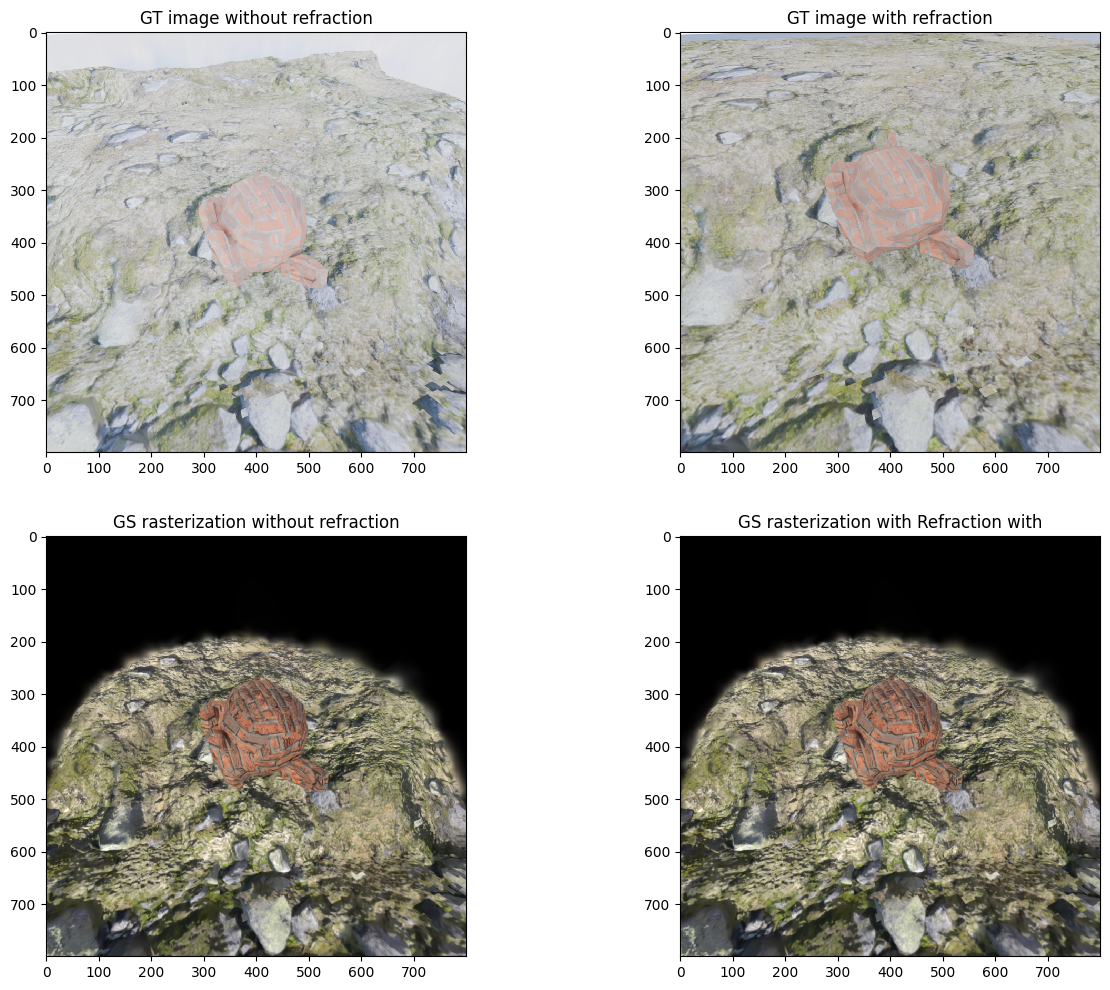

In [9]:
# Display
gt_image_path_wo_ref = os.path.join(wo_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_wo_ref = plt.imread(gt_image_path_wo_ref)
print(f"GT image without refraction: {gt_image_path_wo_ref}")

gt_image_path_with_ref = os.path.join(with_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_with_ref = plt.imread(gt_image_path_with_ref)
print(f"GT image with refraction: {gt_image_path_with_ref}")

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(gt_image_wo_ref)
ax[0, 0].set_title("GT image without refraction")
ax[0, 1].imshow(gt_image_with_ref)
ax[0, 1].set_title("GT image with refraction")
ax[1, 0].imshow(rgb_wo_refraction)
ax[1, 0].set_title("GS rasterization without refraction")
ax[1, 1].imshow(rgb_refraction_wo_quats)
ax[1, 1].set_title("GS rasterization with Refraction with")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1169591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.083944].


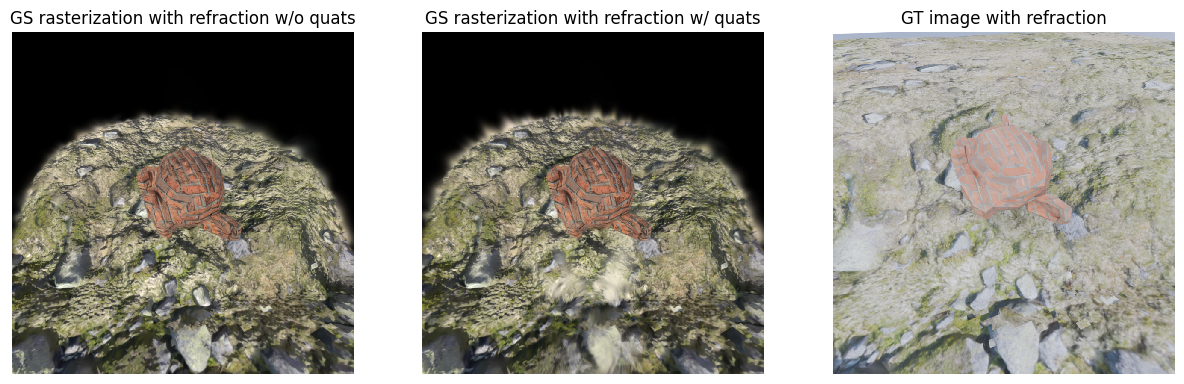

In [10]:
fig, axes = plt.subplots(1, 3)
images = [
    (rgb_refraction_wo_quats, "GS rasterization with refraction w/o quats"),
    (rgb_refraction_with_quats, "GS rasterization with refraction w/ quats"),
    (gt_image_with_ref, "GT image with refraction"),
]
for ax, (img, title) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.show()


In [11]:
from internal.utils.gaussian_utils import GaussianTransformUtils
from optical.utils.rotation_utils import quat_from_2dirs, quat_to_rotmat


ray_intersec2gaussian = WS.ray_intersec2gaussian
ray_to_apparent = WS.ray_to_apparent

d_q = quat_from_2dirs(ray_intersec2gaussian, ray_to_apparent)
print("d_q \n", d_q)

rotmat = quat_to_rotmat(d_q)
print("rotmat \n", rotmat)


d_q 
 tensor([[ 9.8849e-01, -1.3066e-01,  7.6221e-02, -3.5556e-08],
        [ 9.8571e-01, -1.1817e-01,  1.2002e-01, -3.0605e-08],
        [ 9.8372e-01, -1.3035e-01,  1.2373e-01, -7.0714e-08],
        ...,
        [ 9.8380e-01,  8.7162e-02,  1.5665e-01, -2.3078e-08],
        [ 9.8426e-01,  9.2248e-02,  1.5073e-01,  9.5530e-08],
        [ 9.6907e-01,  2.0119e-01,  1.4289e-01,  2.3910e-07]], device='cuda:0',
       grad_fn=<DivBackward0>)
rotmat 
 tensor([[[ 0.9884, -0.0199,  0.1507],
         [-0.0199,  0.9659,  0.2583],
         [-0.1507, -0.2583,  0.9542]],

        [[ 0.9712, -0.0284,  0.2366],
         [-0.0284,  0.9721,  0.2330],
         [-0.2366, -0.2330,  0.9433]],

        [[ 0.9694, -0.0323,  0.2434],
         [-0.0323,  0.9660,  0.2565],
         [-0.2434, -0.2565,  0.9354]],

        ...,

        [[ 0.9509,  0.0273,  0.3082],
         [ 0.0273,  0.9848, -0.1715],
         [-0.3082,  0.1715,  0.9357]],

        [[ 0.9546,  0.0278,  0.2967],
         [ 0.0278,  0.9830, -0.1816

In [12]:
new_quats = GaussianTransformUtils.quat_multiply(quats, d_q)
print("new_quats \n", new_quats)

diff_dir = ray_intersec2gaussian - ray_to_apparent
print("diff_dir \n", diff_dir)

new_quats 
 tensor([[ 0.5514, -0.2143,  0.8048, -0.0487],
        [ 0.2334,  0.6399,  0.2605,  0.6843],
        [ 0.4915,  0.3138,  0.5467,  0.6009],
        ...,
        [ 0.4215,  0.5578,  0.6351,  0.3285],
        [ 0.1367,  0.6015,  0.7152,  0.3287],
        [ 0.0699,  0.6991,  0.0496,  0.7099]], device='cuda:0',
       grad_fn=<CatBackward0>)
diff_dir 
 tensor([[ 0.1034,  0.1773, -0.2223],
        [ 0.1532,  0.1508, -0.2594],
        [ 0.1516,  0.1597, -0.2841],
        ...,
        [ 0.1923, -0.1070, -0.2831],
        [ 0.1867, -0.1143, -0.2775],
        [ 0.1389, -0.1956, -0.4313]], device='cuda:0', grad_fn=<SubBackward0>)


In [13]:
print("ray_intersec2gaussian \n", ray_intersec2gaussian)
print("ray_to_apparent \n", ray_to_apparent)

ray_intersec2gaussian 
 tensor([[-0.3142, -0.5386, -0.7817],
        [-0.4642, -0.4570, -0.7587],
        [-0.4594, -0.4840, -0.7447],
        ...,
        [-0.5826,  0.3242, -0.7453],
        [-0.5658,  0.3463, -0.7483],
        [-0.4209,  0.5927, -0.6867]], device='cuda:0', grad_fn=<DivBackward0>)
ray_to_apparent 
 tensor([[-0.4176, -0.7159, -0.5595],
        [-0.6174, -0.6079, -0.4994],
        [-0.6110, -0.6438, -0.4607],
        ...,
        [-0.7749,  0.4312, -0.4622],
        [-0.7525,  0.4605, -0.4708],
        [-0.5599,  0.7883, -0.2554]], device='cuda:0', grad_fn=<DivBackward0>)


# Time Complexity of Algorithms

In [14]:
# import time

# # instantiate two WaterSruface solvers
# RT_ferrari = WaterSruface(
#     means=means,
#     quats=quats,
#     cam_center=cam_center,
#     n=n,
#     plane=plane,
#     flag_solve_quartic_by_newton=False,
# )
# RT_newton = WaterSruface(
#     means=means,
#     quats=quats,
#     cam_center=cam_center,
#     n=n,
#     plane=plane,
#     flag_solve_quartic_by_newton=True,
# )

# # warm up CUDA
# torch.cuda.synchronize()

# # time Ferrari solver
# start = time.time()
# for _ in range(1000):
#     _ = RT_ferrari.transform_to_appearance()
# torch.cuda.synchronize()
# time_ferrari = time.time() - start

# # time Newton solver
# start = time.time()
# for _ in range(1000):
#     _ = RT_newton.transform_to_appearance()
# torch.cuda.synchronize()
# time_newton = time.time() - start

# print(f"Ferrari solver: {time_ferrari:.4f} s for 1000 runs")
# print(f"Newton solver:  {time_newton:.4f} s for 1000 runs")